In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
import random
from PIL import Image
import os
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=512):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.img_files = sorted(os.listdir(img_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

        # Image transform (NORMALIZE only images)
        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

        # Mask transform (NO NORMALIZATION)
        self.mask_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.img_transform(img)
        mask = self.mask_transform(mask)

        # Binarize mask (VERY IMPORTANT!)
        mask = (mask > 0.5).float()

        return img, mask


In [ ]:
train_imgs = "/content/drive/MyDrive/Drive-2/train/images"
train_masks = "/content/drive/MyDrive/Drive-2/train/mask"

test_imgs = "/content/drive/MyDrive/Drive-2/test/images"
test_masks = "/content/drive/MyDrive/Drive-2/test/mask"

from torch.utils.data import random_split, DataLoader
train_dataset = SegmentationDataset(train_imgs, train_masks)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])


test_dataset = SegmentationDataset(test_imgs, test_masks)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target, smooth=1e-6):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        inter = (pred * target).sum()
        return 1 - (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

def dice_coef(pred, target, eps=1e-6):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    inter = (pred * target).sum()
    return (2*inter + eps) / (pred.sum() + target.sum() + eps)

def jaccard_coef(pred, target, eps=1e-6):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + eps) / (union + eps)


In [ ]:


class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()

        self.inorm = nn.InstanceNorm2d(
            in_channels, affine=True, track_running_stats=False
        )

        self.act = nn.LeakyReLU(0.1, inplace=True)

        self.conv = nn.Conv2d(
            in_channels, growth_rate,
            kernel_size=3, padding=1, bias=False
        )

    def forward(self, x):
        new_feat = self.conv(self.act(self.inorm(x)))
        return torch.cat([x, new_feat], dim=1)


class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate=16, n_layers=3):
        super(DenseBlock, self).__init__()
        self.layers = nn.ModuleList()
        ch = in_channels
        for _ in range(n_layers):
            self.layers.append(DenseLayer(ch, growth_rate))
            ch += growth_rate
        self.out_channels = ch

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x



class ChannelAttention(nn.Module):
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_ch, in_ch // reduction),
            nn.LeakyReLU(0.1, inplace=True),  # 🔥 ReLU → LeakyReLU
            nn.Linear(in_ch // reduction, in_ch),
        )
        self.sig = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg = torch.mean(x, dim=(2, 3))
        maxv, _ = torch.max(x.view(b, c, -1), dim=2)
        w = self.sig(self.fc(avg) + self.fc(maxv)).view(b, c, 1, 1)
        return x * w


class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.cat([avg, maxv], dim=1)
        return x * self.sig(self.conv(attn))


class CBAM(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.ca = ChannelAttention(in_ch)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


class RegionExtractor(nn.Module):
    def __init__(self, scales=(1, 2, 4)):
        super().__init__()
        self.scales = scales

    def forward(self, x):
        b, c, h, w = x.shape
        outs = []
        for s in self.scales:
            pooled = F.adaptive_avg_pool2d(x, (max(1, h // s), max(1, w // s)))
            up = F.interpolate(pooled, size=(h, w), mode="bilinear", align_corners=False)
            outs.append(up)
        return torch.cat(outs, dim=1)


class BottleneckMHSA(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv_attn = nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, groups=in_ch)
        self.proj = nn.Conv2d(in_ch, in_ch, kernel_size=1)

    def forward(self, x):
        attn = torch.sigmoid(self.conv_attn(x))
        return self.proj(x * attn)


class FACB(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.re = RegionExtractor()
        self.reduce = nn.Conv2d(in_ch * 3, in_ch, kernel_size=1)
        self.cbam = CBAM(in_ch)
        self.mhsa = BottleneckMHSA(in_ch)

    def forward(self, x):
        x = self.re(x)
        x = self.reduce(x)
        x = self.cbam(x)
        x = self.mhsa(x)
        return x


class DenseFACB(nn.Module):
    def __init__(
        self,
        in_ch=3,
        out_ch=1,
        growth=16,
        dense_layer=4,
    ):
        super().__init__()

        # Encoder
        self.enc1 = DenseBlock(in_ch, growth, dense_layer)
        ch1 = self.enc1.out_channels

        self.enc2 = DenseBlock(ch1, growth, dense_layer)
        ch2 = self.enc2.out_channels

        self.enc3 = DenseBlock(ch2, growth, dense_layer)
        ch3 = self.enc3.out_channels

        self.enc4 = DenseBlock(ch3, growth, dense_layer)
        ch4 = self.enc4.out_channels

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DenseBlock(ch4, growth, dense_layer)
        bottleneck_ch = self.bottleneck.out_channels
        self.facb_bottleneck = FACB(bottleneck_ch)

        # FACB on skip features
        self.facb_e1 = FACB(ch1)
        self.facb_e2 = FACB(ch2)
        self.facb_e3 = FACB(ch3)
        self.facb_e4 = FACB(ch4)

        # Decoder
        self.up4 = nn.ConvTranspose2d(bottleneck_ch, ch4, 2, 2)
        self.dec4 = DenseBlock(ch4 + ch4, growth, dense_layer)

        self.up3 = nn.ConvTranspose2d(self.dec4.out_channels, ch3, 2, 2)
        self.dec3 = DenseBlock(ch3 + ch3, growth, dense_layer)

        self.up2 = nn.ConvTranspose2d(self.dec3.out_channels, ch2, 2, 2)
        self.dec2 = DenseBlock(ch2 + ch2, growth, dense_layer)

        self.up1 = nn.ConvTranspose2d(self.dec2.out_channels, ch1, 2, 2)
        self.dec1 = DenseBlock(ch1 + ch1, growth, dense_layer)

        self.final = nn.Conv2d(self.dec1.out_channels, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))
        b = self.facb_bottleneck(b)

        e1 = self.facb_e1(e1)
        e2 = self.facb_e2(e2)
        e3 = self.facb_e3(e3)
        e4 = self.facb_e4(e4)

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)

In [ ]:
model = DenseFACB(in_ch=3, out_ch=1,growth=8, dense_layer=5)
criterion = lambda pred, target: 0.5 * nn.BCEWithLogitsLoss()(pred, target) + 0.5 * DiceLoss()(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Model moved to device:", next(model.parameters()).device)

Model moved to device: cuda:0


In [ ]:
def compute_metrics(pred, target, eps=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)

    TP = ((pred == 1) & (target == 1)).sum().float()
    TN = ((pred == 0) & (target == 0)).sum().float()
    FP = ((pred == 1) & (target == 0)).sum().float()
    FN = ((pred == 0) & (target == 1)).sum().float()

    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)
    sensitivity = TP / (TP + FN + eps)
    specificity = TN / (TN + FP + eps)

    return accuracy.item(), sensitivity.item(), specificity.item()


In [ ]:
print('train with 100 epoch')

num_epochs = 100
model = model.to(device)
print("Model moved to device:", next(model.parameters()).device)

bce = nn.BCEWithLogitsLoss()
dice_loss_fn = DiceLoss()

def combined_loss(pred, target):
    return 0.5 * bce(pred, target) + 0.5 * dice_loss_fn(pred, target)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_dice = 0.0
best_epoch = 0
best_model_path = "best_model_dice.pth"

print("Training started...")

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_dataset)


    model.eval()
    total_dice = total_iou = 0.0
    total_acc = total_sen = total_spe = 0.0
    count = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.45).float()

            total_dice += dice_coef(preds, masks).item()
            total_iou += jaccard_coef(preds, masks).item()

            acc, sen, spe = compute_metrics(preds, masks)
            total_acc += acc
            total_sen += sen
            total_spe += spe
            count += 1

    avg_dice = total_dice / count
    avg_iou  = total_iou  / count
    avg_acc  = total_acc  / count
    avg_sen  = total_sen  / count
    avg_spe  = total_spe  / count


    if avg_dice > best_dice:
        best_dice = avg_dice
        best_epoch = epoch + 1

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_dice": best_dice
        }, best_model_path)

        print(f"Best model saved at epoch {best_epoch} with Val Dice = {best_dice:.4f}")

    scheduler.step(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Loss: {epoch_loss:.4f} | "
          f"Val Dice: {avg_dice:.4f} | Val IoU: {avg_iou:.4f} | "
          f"Acc: {avg_acc:.4f} | Sensitivity: {avg_sen:.4f} | "
          f"Specificity: {avg_spe:.4f}")

print("Training Finished!")
print(f"Best Val Dice: {best_dice:.4f} at epoch {best_epoch}")
print("Model saved as:", best_model_path)


train with 100 epoch
Model moved to device: cuda:0
Training started...
Best model saved at epoch 1 with Val Dice = 0.5188
Epoch 1/100 | Loss: 1.0747 | Val Dice: 0.5188 | Val IoU: 0.3523 | Acc: 0.8808 | Sensitivity: 0.6715 | Specificity: 0.9036
Best model saved at epoch 2 with Val Dice = 0.6823
Epoch 2/100 | Loss: 0.3460 | Val Dice: 0.6823 | Val IoU: 0.5205 | Acc: 0.9359 | Sensitivity: 0.7203 | Specificity: 0.9596
Best model saved at epoch 3 with Val Dice = 0.7084
Epoch 3/100 | Loss: 0.2621 | Val Dice: 0.7084 | Val IoU: 0.5507 | Acc: 0.9466 | Sensitivity: 0.6829 | Specificity: 0.9753
Best model saved at epoch 4 with Val Dice = 0.7223
Epoch 4/100 | Loss: 0.2461 | Val Dice: 0.7223 | Val IoU: 0.5678 | Acc: 0.9445 | Sensitivity: 0.7608 | Specificity: 0.9647
Best model saved at epoch 5 with Val Dice = 0.7328
Epoch 5/100 | Loss: 0.2345 | Val Dice: 0.7328 | Val IoU: 0.5808 | Acc: 0.9492 | Sensitivity: 0.7366 | Specificity: 0.9724
Epoch 6/100 | Loss: 0.2285 | Val Dice: 0.7256 | Val IoU: 0.5720 

In [ ]:

import torch
import numpy as np

def evaluate_model(model, loader, device, threshold=0.45):
    model.eval()

    total_dice = 0.0
    total_iou  = 0.0
    total_acc  = 0.0
    total_sen  = 0.0
    total_spe  = 0.0
    count = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(imgs)

            # Handle shape differences: [B,H,W] -> [B,1,H,W]
            if logits.dim() == 3:
                logits = logits.unsqueeze(1)
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            total_dice += dice_coef(preds, masks).item()
            total_iou  += jaccard_coef(preds, masks).item()

            acc, sen, spe = compute_metrics(preds, masks)
            total_acc += acc
            total_sen += sen
            total_spe += spe

            count += 1

    return {
        "dice": total_dice / max(count, 1),
        "iou":  total_iou  / max(count, 1),
        "acc":  total_acc  / max(count, 1),
        "sen":  total_sen  / max(count, 1),
        "spe":  total_spe  / max(count, 1),
    }


best_model_path = "best_model_dice.pth"
checkpoint = torch.load(best_model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print(f"Loaded best model from epoch {checkpoint.get('epoch')} "
      f"(best_dice={checkpoint.get('best_dice', None)})")

print("Testing on test_loader...")
metrics = evaluate_model(model, test_loader, device, threshold=0.45)

print("\n===== TEST RESULTS =====")
print(f"Dice        : {metrics['dice']:.4f}")
print(f"IoU         : {metrics['iou']:.4f}")
print(f"Accuracy    : {metrics['acc']:.4f}")
print(f"Sensitivity : {metrics['sen']:.4f}")
print(f"Specificity : {metrics['spe']:.4f}")


Loaded best model from epoch 100 (best_dice=0.8261501677334309)
Testing on test_loader...

===== TEST RESULTS =====
Dice        : 0.8009
IoU         : 0.6681
Accuracy    : 0.9618
Sensitivity : 0.8026
Specificity : 0.9789


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(model, loader, device, threshold=0.45, max_images=6):
    model.eval()
    shown = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)

            # Shape safety
            if logits.dim() == 3:
                logits = logits.unsqueeze(1)
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            for i in range(imgs.size(0)):
                img  = imgs[i].detach().cpu()
                gt   = masks[i].detach().cpu()
                pred = preds[i].detach().cpu()

                # Convert image
                if img.shape[0] == 1:
                    img = img[0]
                else:
                    img = img.permute(1, 2, 0)

                gt   = gt.squeeze()
                pred = pred.squeeze()

                plt.figure(figsize=(12, 4))

                plt.subplot(1, 3, 1)
                plt.imshow(img, cmap="gray")
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(gt, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.show()

                shown += 1
                if shown >= max_images:
                    return


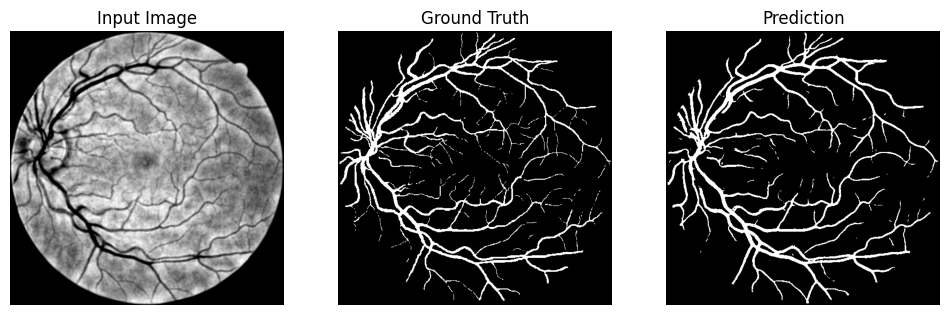

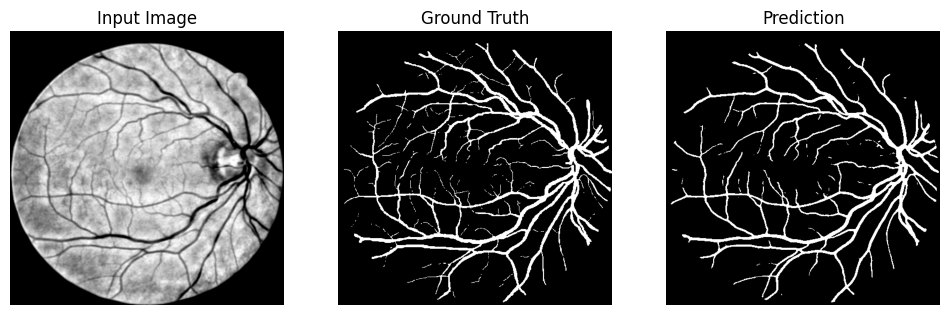

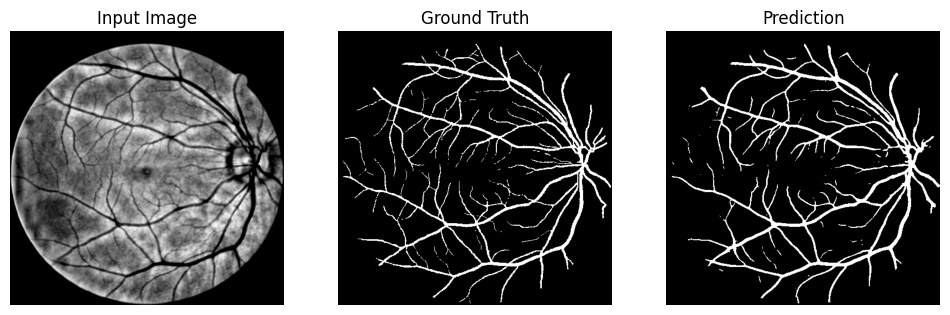

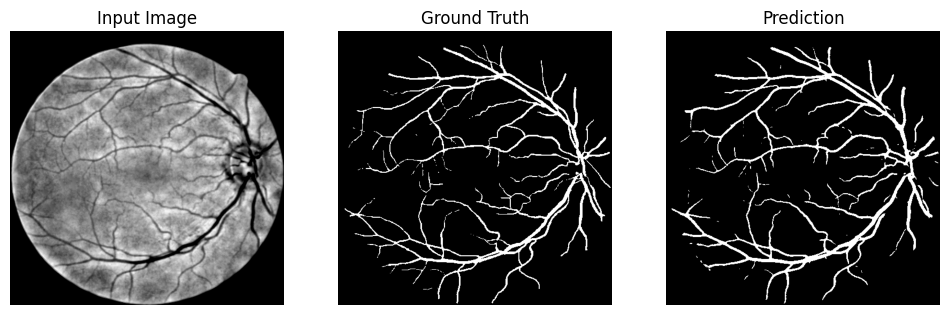

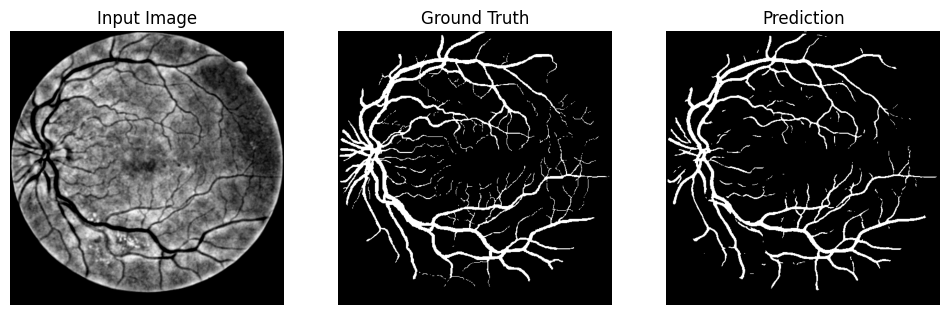

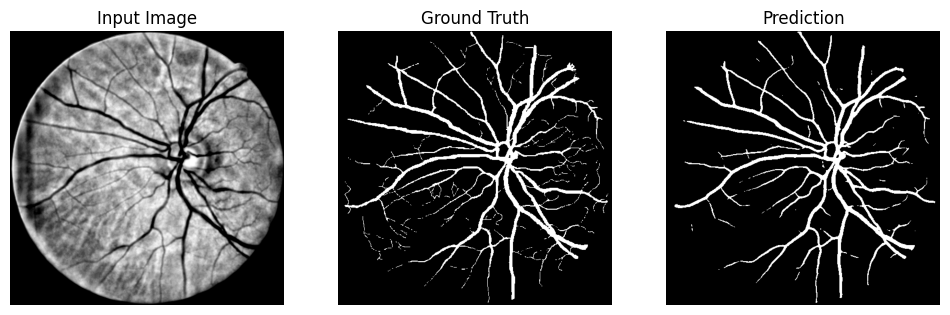

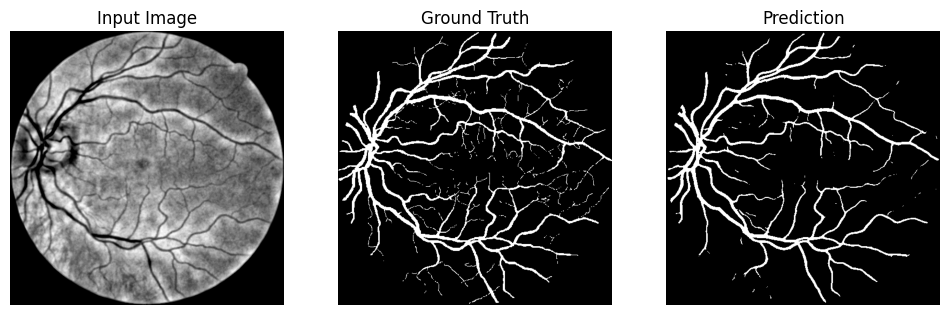

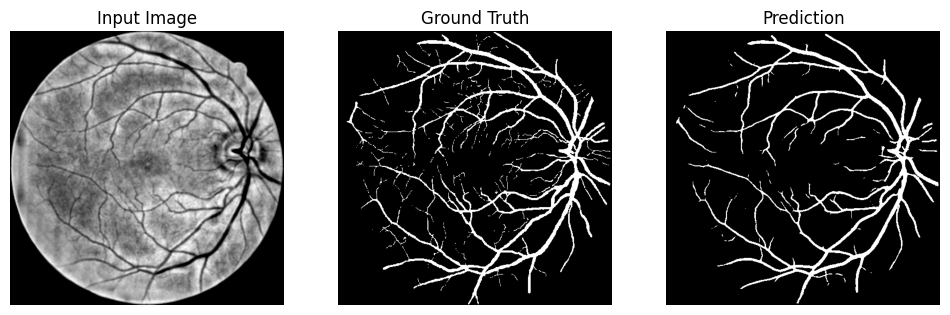

In [ ]:
show_predictions(
    model=model,
    loader=test_loader,
    device=device,
    threshold=0.45,
    max_images=8
)
